# Baseline — Random Forest

Ensemble de árvores (não extrapola). Grid search no mesmo CV; compara com a DNN, inclusive no LOPO.

## Setup

In [1]:
import os, sys
# garante o cwd na raiz do repo (onde ficam data/ e support_scripts/)
while not os.path.isdir('support_scripts') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.append('support_scripts')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import data_prep as dp, sk_eval

d = dp.get_data()
print(f"{len(d['df'])} animais | {len(d['scale_cols'])} preditores | "
      f"{d['groups'].value_counts().to_dict()}")
from sklearn.ensemble import RandomForestRegressor
from itertools import product

245 animais | 9 preditores | {'elvis': 113, 'humberto': 71, 'sonico': 61}


## Grid search (CV 10-fold)

In [2]:
rf_grid = dict(n_estimators=[400], max_depth=[None, 6, 10],
               min_samples_leaf=[1, 3, 5])
rows, cfgs = [], []
for vals in product(*rf_grid.values()):
    p = dict(zip(rf_grid, vals)); cfgs.append(p)
    cv = sk_eval.cv_eval(d, lambda p=p: RandomForestRegressor(**p, random_state=dp.SEED, n_jobs=-1),
                         scale=False)
    rows.append({**p, 'R2': round(cv.R2.mean(), 4), 'MAE': round(cv.MAE.mean(), 4)})
best_rf = cfgs[int(np.argmax([r['R2'] for r in rows]))]   # da lista (tipos preservados)
rf_res = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
print('melhor RF:', best_rf)
rf_res

melhor RF: {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 3}


,n_estimators,max_depth,min_samples_leaf,R2,MAE
0,400,NaN,3,0.4802,0.0554
1,400,10.0,3,0.4759,0.0559
2,400,NaN,1,0.4546,0.0561
3,400,NaN,5,0.4529,0.0575
4,400,10.0,5,0.4514,0.0577
5,400,10.0,1,0.4474,0.0574
6,400,6.0,3,0.4312,0.0597
7,400,6.0,5,0.4173,0.0604
8,400,6.0,1,0.4138,0.0609


## CV + LOPO do melhor RF (grava no comparativo)

In [3]:
mk_rf = lambda: RandomForestRegressor(**best_rf, random_state=dp.SEED, n_jobs=-1)
res = sk_eval.registrar('RandomForest', mk_rf, scale=False, d=d)
res['lopo']

RandomForest: CV R2 sem=0.480 / com jitter=0.463  | MAE=0.0554
  LOPO R2: {'elvis': -0.08, 'sonico': -0.13, 'humberto': 0.31}


,testa,MAE,RMSE,R2
0,elvis,0.0703,0.0954,-0.0842
1,sonico,0.0659,0.0802,-0.1339
2,humberto,0.0972,0.1391,0.3063


## Importância das features

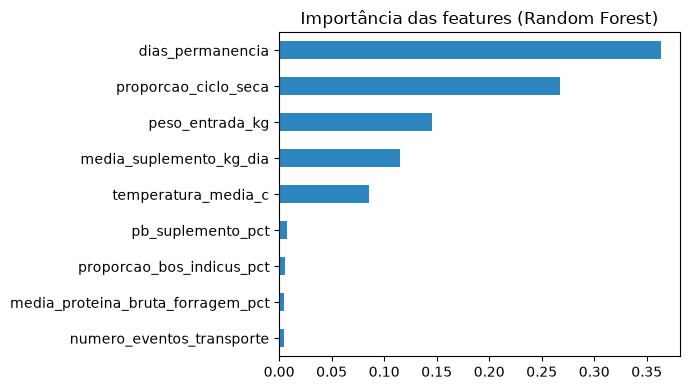

numero_eventos_transporte            0.005
media_proteina_bruta_forragem_pct    0.005
proporcao_bos_indicus_pct            0.006
pb_suplemento_pct                    0.008
temperatura_media_c                  0.086
media_suplemento_kg_dia              0.115
peso_entrada_kg                      0.145
proporcao_ciclo_seca                 0.268
dias_permanencia                     0.363
dtype: float64

In [4]:
rf = RandomForestRegressor(**best_rf, random_state=dp.SEED, n_jobs=-1)
rf.fit(d['df'][d['scale_cols']], d['df'][dp.TARGET])
imp = pd.Series(rf.feature_importances_, index=d['scale_cols']).sort_values()
imp.plot.barh(figsize=(7, 4), color='#2e86c1')
plt.title('Importância das features (Random Forest)'); plt.tight_layout(); plt.show()
imp.round(3)

## Predito × real (out-of-fold)

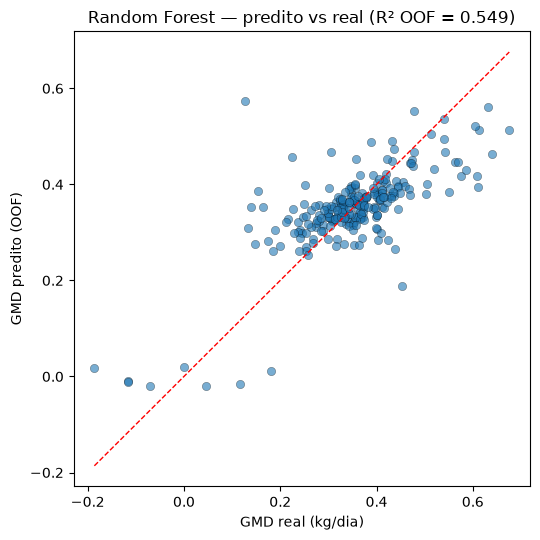

In [5]:
y = d['df'][dp.TARGET].values
yp = sk_eval.oof(d, mk_rf, scale=False)
r2 = dp.metrics(y, yp)['R2']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y, yp, alpha=.6, edgecolor='k', linewidth=.3)
lims = [min(y.min(), yp.min()), max(y.max(), yp.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('GMD real (kg/dia)'); ax.set_ylabel('GMD predito (OOF)')
ax.set_title(f'Random Forest — predito vs real (R² OOF = {r2:.3f})')
plt.tight_layout(); plt.show()